# Ultrasound Baseline Experiments

Minimal notebook for evaluating **off-the-shelf OpenAI CLIP** and **BiomedCLIP** on paired ultrasound image-caption data.

In [27]:
# Install dependencies (run once)
!pip install -q transformers open_clip_torch pandas pillow matplotlib scikit-learn tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from transformers import CLIPModel, CLIPProcessor
from open_clip import create_model_from_pretrained, get_tokenizer

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [37]:
config = {
    # Change the folder path here to the one with preprocessed data
    "prepared_data_root": "/Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed",

    # OpenAI CLIP
    "openai_clip_model_name": "openai/clip-vit-base-patch32",

    # BiomedCLIP
    "biomedclip_model_name": "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",

    # Evaluation
    "test_size": 0.15,
    "random_seed": 42, # Fix random seed for reproducibility
    "batch_size": 32,
}

## Load and combine all prepared datasets

In [38]:
def discover_datasets(root):
    """
    Walk the prepared_data root and return all (dataset_name, csv_path) pairs.
    A dataset folder is any directory that directly contains at least one .csv.
    If a folder has multiple CSVs, the largest one is used.
    """
    datasets = []
    for dirpath, dirnames, filenames in os.walk(root):
        csv_files = [f for f in filenames if f.lower().endswith(".csv")]
        if csv_files:
            dataset_name = os.path.basename(dirpath)
            csv_full = [os.path.join(dirpath, f) for f in csv_files]
            csv_full.sort(key=os.path.getsize, reverse=True)
            datasets.append((dataset_name, csv_full[0]))
    return sorted(datasets)


PATH_COL_CANDIDATES = [
    "file_name", "image_name", "path", "filename", "image_path", "filepath",
    "file", "image", "img_path", "img", "image_file"
]
CAPTION_COL_CANDIDATES = [
    "caption", "text_caption", "text_captions", "description", "text", "label",
    "report", "finding", "findings", "annotation", "sentence"
]

def detect_column(df_columns, candidates):
    cols_lower = {c.lower(): c for c in df_columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def load_dataset_csv(csv_path, dataset_name):
    df = pd.read_csv(csv_path)
    path_col = detect_column(df.columns, PATH_COL_CANDIDATES)
    cap_col  = detect_column(df.columns, CAPTION_COL_CANDIDATES)

    if path_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect image path column. "
            f"Available: {list(df.columns)}"
        )
    if cap_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect caption column. "
            f"Available: {list(df.columns)}"
        )

    out = df[[path_col, cap_col]].copy()
    out.columns = ["image_path", "caption"]
    out["dataset"] = dataset_name
    return out

def resolve_image_path(raw_path, csv_dir):
    if pd.isna(raw_path):
        return None
    raw_path = str(raw_path).strip()
    candidates = []
    p = Path(raw_path)

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append(Path(csv_dir) / raw_path)
        candidates.append(Path(csv_dir) / p.name)

    for cand in candidates:
        if cand.exists():
            return str(cand.resolve())
    return None

In [39]:
datasets_found = discover_datasets(config["prepared_data_root"])
print(f"Found {len(datasets_found)} dataset(s) under: {config['prepared_data_root']}\n")
for name, csv_path in datasets_found:
    print(f"  {name:40s} -> {csv_path}")

all_dfs = []
load_report = []

for dataset_name, csv_path in datasets_found:
    csv_dir = os.path.dirname(csv_path)

    try:
        df = load_dataset_csv(csv_path, dataset_name)
    except Exception as e:
        print(f"[CSV ERROR] {dataset_name}: {e}")
        load_report.append((dataset_name, 0, 0, "CSV_ERROR"))
        continue

    resolved, n_ok, n_fail = [], 0, 0
    for raw_path in df["image_path"]:
        p = resolve_image_path(raw_path, csv_dir)
        resolved.append(p)
        if p is not None:
            n_ok += 1
        else:
            n_fail += 1

    df["resolved_path"] = resolved
    df_ok = df[df["resolved_path"].notna()].copy()
    df_ok["image_path"] = df_ok["resolved_path"]
    df_ok = df_ok.drop(columns=["resolved_path"])

    if len(df_ok) > 0:
        all_dfs.append(df_ok)

    status = "OK" if n_fail == 0 else f"{n_fail} missing"
    load_report.append((dataset_name, n_ok, n_fail, status))

print("\n" + "=" * 72)
print(f'{"Dataset":<38} {"Loaded":>8} {"Failed":>8}  Status')
print("=" * 72)
for name, n_ok, n_fail, status in load_report:
    ok_str = f"{n_ok:,}" if n_ok else "-"
    fail_str = f"{n_fail:,}" if n_fail else "-"
    print(f"{name:<38} {ok_str:>8} {fail_str:>8}  {status}")
print("=" * 72)

if not all_dfs:
    raise RuntimeError(
        "No data loaded successfully! "
        f"Check prepared_data_root: {config['prepared_data_root']}"
    )

full_df = pd.concat(all_dfs, ignore_index=True)[["image_path", "caption", "dataset"]]
print(f"\nCombined dataset: {len(full_df):,} samples from {full_df['dataset'].nunique()} source(s)")
display(full_df.head())

Found 5 dataset(s) under: /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed

  AULI_resized_images                      -> /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed/Liver_ultrasound/AULI_resized_images/captions.csv
  BrEaST-Lesions_USG-images_and_masks      -> /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed/BrEaST-Lesions_USG-images_and_masks/captions.csv
  Dataset_BUSI_with_GT                     -> /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed/Dataset_BUSI_with_GT/all_captions.csv
  dataset_thyroid_resized_png              -> /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed/Thyroid/dataset_thyroid_resized_png/thyroid_template_captions_with_paths.csv
  final_data                               -> /Users/guest/Coding/Harvard/AIM2/project/BMI702_project/dataset/preprocessed/Lung_ultrasound/final_data/lung_captions.csv

Dataset              

,image_path,caption,dataset
0,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,"A B-mode ultrasound of liver, consistent with ...",AULI_resized_images
1,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,An ultrasound image of liver with benign findi...,AULI_resized_images
2,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,"A clinical ultrasound scan of liver, indicativ...",AULI_resized_images
3,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,This ultrasound demonstrates liver exhibiting ...,AULI_resized_images
4,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,This ultrasound demonstrates liver exhibiting ...,AULI_resized_images


## Create a held-out test split (CHANGE HERE FOR DATA SPLITTING)

In [40]:
def safe_split(df, test_size, stratify_col, seed):
    try:
        return train_test_split(
            df,
            test_size=test_size,
            stratify=df[stratify_col],
            random_state=seed,
        )
    except ValueError as e:
        print(f"[WARNING] Stratified split failed ({e}). Using random split.")
        return train_test_split(df, test_size=test_size, random_state=seed)

_, test_df = safe_split(full_df, config["test_size"], "dataset", config["random_seed"])
test_df = test_df.reset_index(drop=True)

print(f"Test set size: {len(test_df):,}")
print(test_df['dataset'].value_counts())
display(test_df.head())

Test set size: 768
dataset
dataset_thyroid_resized_png            344
final_data                             160
Dataset_BUSI_with_GT                   117
AULI_resized_images                    110
BrEaST-Lesions_USG-images_and_masks     37
Name: count, dtype: int64


,image_path,caption,dataset
0,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,Echographic findings of liver showing benign c...,AULI_resized_images
1,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,"A B-mode ultrasound of the thyroid, labeled be...",dataset_thyroid_resized_png
2,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,"A B-mode ultrasound of breast, consistent with...",Dataset_BUSI_with_GT
3,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,A grayscale ultrasound image demonstrating mal...,dataset_thyroid_resized_png
4,/Users/guest/Coding/Harvard/AIM2/project/BMI70...,Ultrasound of liver presenting sonographic sig...,AULI_resized_images


## Baseline A — OpenAI CLIP zero-shot alignment

In [41]:
print("Loading OpenAI CLIP baseline (zero-shot, no training)...")

openai_clip_model = CLIPModel.from_pretrained(config["openai_clip_model_name"]).to(device).eval()
openai_clip_processor = CLIPProcessor.from_pretrained(config["openai_clip_model_name"])

@torch.no_grad()
def compute_openai_clip_alignment_score_from_df(df, model, processor, device, batch_size=32):
    all_img, all_txt = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP baseline"):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        texts = batch_df["caption"].tolist()

        inputs = processor(
            text=texts,
            images=pil_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        outputs = model(**inputs)
        image_features = F.normalize(outputs.image_embeds, dim=-1)
        text_features  = F.normalize(outputs.text_embeds,  dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim    = img_embs @ txt_embs.T
    off_mask   = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim  = all_sim[off_mask].mean().item()

    print(f"  OpenAI CLIP paired similarity:   {paired_sim:.4f}")
    print(f"  OpenAI CLIP cross-pair mean sim: {cross_sim:.4f}")
    return paired_sim, cross_sim

score_openai_clip, cross_openai_clip = compute_openai_clip_alignment_score_from_df(
    test_df, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)

Loading OpenAI CLIP baseline (zero-shot, no training)...



Loading weights: 100%|█████████████████████| 398/398 [00:00<00:00, 45419.08it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

OpenAI CLIP baseline: 100%|█████████████████████| 24/24 [00:12<00:00,  1.91it/s]

  OpenAI CLIP paired similarity:   0.3297
  OpenAI CLIP cross-pair mean sim: 0.3273


## Baseline B — BiomedCLIP zero-shot alignment

In [42]:
print("Loading BiomedCLIP baseline (zero-shot, no training)...")

biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(config["biomedclip_model_name"])
biomedclip_tokenizer = get_tokenizer(config["biomedclip_model_name"])
biomedclip_model = biomedclip_model.to(device).eval()

@torch.no_grad()
def compute_biomedclip_alignment_score_from_df(df, model, preprocess, tokenizer, device, batch_size=32):
    all_img, all_txt = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP baseline"):
        batch_df = df.iloc[start:start + batch_size]

        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)

        texts = batch_df["caption"].tolist()
        text_tokens = tokenizer(texts, context_length=256).to(device)

        image_features = model.encode_image(images)
        text_features  = model.encode_text(text_tokens)

        image_features = F.normalize(image_features, dim=-1)
        text_features  = F.normalize(text_features, dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim    = img_embs @ txt_embs.T
    off_mask   = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim  = all_sim[off_mask].mean().item()

    print(f"  BiomedCLIP paired similarity:   {paired_sim:.4f}")
    print(f"  BiomedCLIP cross-pair mean sim: {cross_sim:.4f}")
    return paired_sim, cross_sim

score_biomedclip, cross_biomedclip = compute_biomedclip_alignment_score_from_df(
    test_df, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device,
    batch_size=config["batch_size"]
)

Loading BiomedCLIP baseline (zero-shot, no training)...



BiomedCLIP baseline: 100%|██████████████████████| 24/24 [00:52<00:00,  2.20s/it]

  BiomedCLIP paired similarity:   0.4327
  BiomedCLIP cross-pair mean sim: 0.3615


## Results

,model,paired_similarity,cross_pair_similarity
0,OpenAI CLIP,0.329738,0.327287
1,BiomedCLIP,0.432661,0.361475


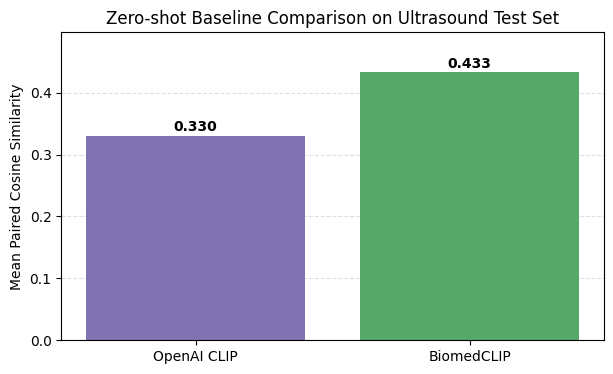

In [43]:
results = pd.DataFrame({
    "model": ["OpenAI CLIP", "BiomedCLIP"],
    "paired_similarity": [score_openai_clip, score_biomedclip],
    "cross_pair_similarity": [cross_openai_clip, cross_biomedclip],
})
display(results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["model"], results["paired_similarity"], color=["#8172B2", "#55A868"])
for i, v in enumerate(results["paired_similarity"]):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Mean Paired Cosine Similarity")
ax.set_title("Zero-shot Baseline Comparison on Ultrasound Test Set")
ax.set_ylim(min(0, results["paired_similarity"].min() - 0.05), results["paired_similarity"].max() * 1.15)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.show()